In [1]:
import os
import zipfile

zip_filename = 'plantvillage.zip'
target_dir = './tomato_dataset'

# will Download only if zip doesn't exist
if not os.path.exists(zip_filename):
    print("Downloading dataset...")
    !kaggle datasets download -d mohitsingh1804/plantvillage
    print("Download complete!")
else:
    print(f"'{zip_filename}' already exists")

#Extract  only if it hasn't been extracted 
if not os.path.exists(target_dir):
    print("Extracting dataset...")
    os.makedirs(target_dir, exist_ok=True)
    with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
        zip_ref.extractall(target_dir)
    print("Extracted")
else:
    print("already extracted")

'plantvillage.zip' already exists
already extracted


In [2]:
import torch
import torch.nn as nn
from torchvision.models import googlenet, GoogLeNet_Weights
import torchvision
from torchvision.datasets import ImageFolder
import torchvision.transforms.v2 as T
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [3]:
dataset_path = "./tomato_dataset/PlantVillage"

train_dir = f"./tomato_dataset/PlantVillage/train"

val_dir = f"./tomato_dataset/PlantVillage/val"

In [4]:
# Compute Mean and Std 

mean = torch.tensor([0.4496, 0.4651, 0.4003])
std = torch.tensor([0.1656, 0.1448, 0.1831])
dataset_path = "./tomato_dataset/PlantVillage"

train_dir = f"{dataset_path}/train"
val_dir = f"{dataset_path}/val"


# Training Transform

train_transform = T.Compose([

    # Data Augmentation
    T.RandomResizedCrop(
        size=(224, 224),
        scale=(0.8, 1.0),
        ratio=(0.9, 1.1)
    ),

    T.RandomHorizontalFlip(p=0.5),

    T.RandomRotation(degrees=15),

    T.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),

    # Convert to Tensor
    T.ToImage(),

    T.ToDtype(torch.float32, scale=True),

    # Normalize
    T.Normalize(
        mean=mean.tolist(),
        std=std.tolist()
    )
])


# Validation Transform

val_transform = T.Compose([

    T.Resize((224, 224)),

    T.ToImage(),

    T.ToDtype(torch.float32, scale=True),

    T.Normalize(
        mean=mean.tolist(),
        std=std.tolist()
    )
])


# Test-Time Augmentation 


tta_transforms = [

    T.Compose([
        T.Resize((224,224)),
        T.ToImage(),
        T.ToDtype(torch.float32, scale=True),
        T.Normalize(mean.tolist(), std.tolist())
    ]),

    T.Compose([
        T.Resize((224,224)),
        T.RandomHorizontalFlip(p=1.0),
        T.ToImage(),
        T.ToDtype(torch.float32, scale=True),
        T.Normalize(mean.tolist(), std.tolist())
    ]),

    T.Compose([
        T.Resize((224,224)),
        T.RandomRotation(10),
        T.ToImage(),
        T.ToDtype(torch.float32, scale=True),
        T.Normalize(mean.tolist(), std.tolist())
    ])
]

In [5]:
# Dataset


train_data = ImageFolder(
    train_dir,
    transform=train_transform
)

val_data = ImageFolder(
    val_dir,
    transform=val_transform
)

In [6]:

# DataLoader


train_loader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True,
    num_workers=2,
   
)

val_loader = DataLoader(
    val_data,
    batch_size=32,
    shuffle=False,
    num_workers=2,
   
)

print("Classes:", train_data.classes)
print("Training Images:", len(train_data))
print("Validation Images:", len(val_data))

Classes: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
Training Images: 14529
Validation Images: 3631


mps


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /Users/lucky/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████████████████████████████████| 97.8M/97.8M [00:19<00:00, 5.30MB/s]


In [15]:


from torchvision.models import resnet50, ResNet50_Weights

device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)

model = resnet50(
    weights=ResNet50_Weights.DEFAULT
)

model.fc = nn.Linear(
    model.fc.in_features,
    10
)

model = model.to(device)

Total Parameters     : 23,528,522
Trainable Parameters : 23,528,522


In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=3
)

epochs = 20

best_val_loss = float("inf")

patience = 5

counter = 0

In [18]:
from tqdm import tqdm
import torch

epochs = 20

best_val_loss = float("inf")
patience = 5
counter = 0

for epoch in range(epochs):

    
    # Training
    
    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in tqdm(train_loader,
                               desc=f"Epoch {epoch+1}/{epochs}"):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss /= len(train_loader)
    train_acc = 100 * train_correct / train_total

    
    # Validation
   
    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = 100 * val_correct / val_total

    
    # Scheduler
    
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"LR: {current_lr:.6f} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

   
    # Save Best Model
   
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "best_googlenet.pth"
        )

        counter = 0

        print("Best model saved")

    else:

        counter += 1

        print(f"Early Stopping Counter: {counter}/{patience}")

        if counter >= patience:

            print("Early stopping triggered")

            break

print("Training Complete")

Epoch 1/20: 100%|█████████████████████████████| 455/455 [06:21<00:00,  1.19it/s]


Epoch [1/20] | LR: 0.001000 | Train Loss: 0.3289 | Train Acc: 89.30% | Val Loss: 0.2841 | Val Acc: 91.08%
Best model saved.


Epoch 2/20: 100%|█████████████████████████████| 455/455 [07:22<00:00,  1.03it/s]


Epoch [2/20] | LR: 0.001000 | Train Loss: 0.1622 | Train Acc: 94.81% | Val Loss: 0.2287 | Val Acc: 92.37%
Best model saved.


Epoch 3/20: 100%|█████████████████████████████| 455/455 [07:01<00:00,  1.08it/s]


...

Epoch [18/20] | LR: 0.000100 | Train Loss: 0.0088 | Train Acc: 99.75% | Val Loss: 0.0085 | Val Acc: 99.67%
Best model saved.


Epoch 19/20: 100%|████████████████████████████| 455/455 [06:41<00:00,  1.13it/s]


Epoch [19/20] | LR: 0.000100 | Train Loss: 0.0081 | Train Acc: 99.77% | Val Loss: 0.0107 | Val Acc: 99.64%
Early Stopping Counter: 1/5


Epoch 20/20: 100%|████████████████████████████| 455/455 [06:41<00:00,  1.13it/s]


Epoch [20/20] | LR: 0.000100 | Train Loss: 0.0077 | Train Acc: 99.78% | Val Loss: 0.0085 | Val Acc: 99.67%
Best model saved.
Training Complete.


In [21]:
from sklearn.metrics import (

    confusion_matrix,

    classification_report,

    accuracy_score,

    precision_score,

    recall_score,

    f1_score

)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model =  resnet50(num_classes=10).to(device)

model.load_state_dict(

    torch.load(

        "best_googlenet.pth",

        map_location=device

    )

)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

In [22]:
all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

In [23]:
accuracy = accuracy_score(all_labels, all_predictions)

precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted"
)

recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted"
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted"
)

print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 99.67%
Precision: 0.9967
Recall   : 0.9967
F1 Score : 0.9967


In [24]:
report = classification_report(
    all_labels,
    all_predictions,
    target_names=train_data.classes,
    digits=4
)

print(report)

with open("classification_report.txt", "w") as f:
    f.write(report)

                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot     1.0000    0.9906    0.9953       425
                        Tomato___Early_blight     0.9900    0.9950    0.9925       200
                         Tomato___Late_blight     1.0000    0.9974    0.9987       382
                           Tomato___Leaf_Mold     1.0000    1.0000    1.0000       191
                  Tomato___Septoria_leaf_spot     1.0000    0.9972    0.9986       354
Tomato___Spider_mites Two-spotted_spider_mite     0.9940    0.9940    0.9940       335
                         Tomato___Target_Spot     0.9823    0.9893    0.9858       281
       Tomato___Tomato_Yellow_Leaf_Curl_Virus     0.9991    1.0000    0.9995      1071
                 Tomato___Tomato_mosaic_virus     0.9867    1.0000    0.9933        74
                             Tomato___healthy     0.9969    1.0000    0.9984       318

                                     accu

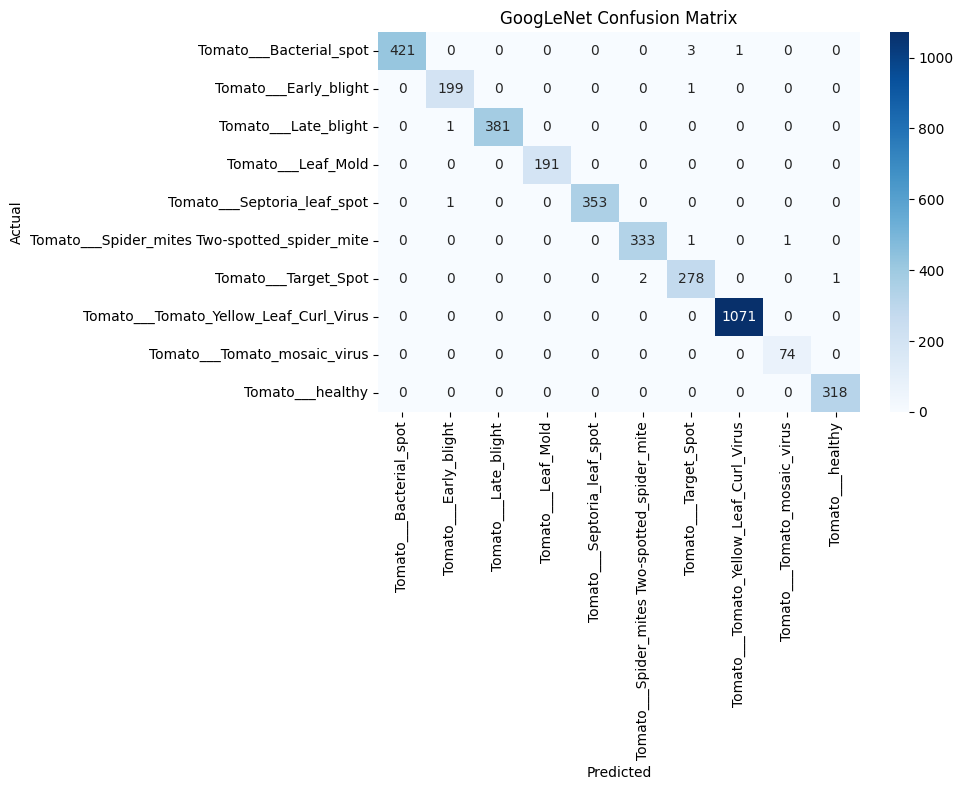

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_data.classes,
    yticklabels=train_data.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("GoogLeNet Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "googlenet_confusion_matrix.png",
    dpi=300
)

plt.show()

In [26]:
import pandas as pd
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

df = pd.DataFrame({

    "Class": train_data.classes,

    "Accuracy (%)": per_class_accuracy * 100

})

print(df)

df.to_csv(
    "per_class_accuracy.csv",
    index=False
)

                                           Class  Accuracy (%)
0                        Tomato___Bacterial_spot     99.058824
1                          Tomato___Early_blight     99.500000
2                           Tomato___Late_blight     99.738220
3                             Tomato___Leaf_Mold    100.000000
4                    Tomato___Septoria_leaf_spot     99.717514
5  Tomato___Spider_mites Two-spotted_spider_mite     99.402985
6                           Tomato___Target_Spot     98.932384
7         Tomato___Tomato_Yellow_Leaf_Curl_Virus    100.000000
8                   Tomato___Tomato_mosaic_virus    100.000000
9                               Tomato___healthy    100.000000


In [27]:


tta_transforms = [

    T.Compose([
        T.Resize((224,224)),
        T.ToImage(),
        T.ToDtype(torch.float32, scale=True),
        T.Normalize(mean.tolist(), std.tolist())
    ]),

    T.Compose([
        T.Resize((224,224)),
        T.RandomHorizontalFlip(p=1.0),
        T.ToImage(),
        T.ToDtype(torch.float32, scale=True),
        T.Normalize(mean.tolist(), std.tolist())
    ]),

    T.Compose([
        T.Resize((224,224)),
        T.RandomRotation(10),
        T.ToImage(),
        T.ToDtype(torch.float32, scale=True),
        T.Normalize(mean.tolist(), std.tolist())
    ])
]

In [28]:
from PIL import Image
def tta_predict(image_path):

    image = Image.open(image_path).convert("RGB")

    probs = []

    for transform in tta_transforms:

        img = transform(image)

        img = img.unsqueeze(0).to(device)

        with torch.no_grad():

            output = model(img)

            probs.append(
                torch.softmax(output, dim=1)
            )

    probs = torch.stack(probs)

    return probs.mean(0)
    

In [29]:
all_labels = []
all_predictions = []

samples = val_data.samples

for image_path, label in samples:

    prediction = tta_predict(image_path)

    pred = prediction.argmax(dim=1).item()

    all_predictions.append(pred)

    all_labels.append(label)
    

In [30]:
tta_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print(
    f"TTA Accuracy : {tta_accuracy*100:.2f}%"
)

TTA Accuracy : 99.75%
